In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from pathlib import Path
import ast
import time

In [44]:
def load_data(raw_base_path, alert_base_path, day_to_load=datetime.now(timezone.utc).strftime("%Y-%m-%d")) -> pd.DataFrame:
 
    raw_path = Path(f"{raw_base_path}/event_dt={day_to_load}")
    alert_path = Path(f"{alert_base_path}/event_dt={day_to_load}")
 
    # Load all CSVs in each partition directory
    raw_df = pd.concat(
        [pd.read_csv(f) for f in raw_path.glob("*.csv")],
        ignore_index=True,
    )
    alert_df = pd.concat(
        [pd.read_csv(f) for f in alert_path.glob("*.csv")],
        ignore_index=True,
    )
 
    # Keep only the row with the largest z-score per unique "column" value
    alert_df = (
        alert_df
        .sort_values("z_score", ascending=False)
        .drop_duplicates(subset="id")
        .reset_index(drop=True)
    )
 
    # Left join: keep all raw rows, attach alert info where available
    merged_df = alert_df.merge(raw_df, on="event_id", how="left")
 
    return merged_df


In [46]:
import matplotlib.dates as mdates


def parse_list_col(val: str, dtype=float) -> list:
    """Parse a stringified Python list into a typed list."""
    parsed = ast.literal_eval(val)
    return [dtype(v) for v in parsed]

def parse_timestamps(val: str) -> list[str]:
    """Parse a stringified list of timestamps without ast.literal_eval.
    Timestamps like '2026-04-21 02:15:00' are unquoted inside the string,
    so ast.literal_eval fails on the leading zeros in time components."""
    stripped = val.strip().lstrip("[").rstrip("]")
    return [ts.strip() for ts in stripped.split(",")]


def plot_anomalies(df: pd.DataFrame, z_threshold: float = 2.0, n_rows: int = 10):
    subset = df.head(n_rows).reset_index(drop=True)

    cols = 2
    rows = (n_rows + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()

    for i, row in subset.iterrows():
        ax = axes[i]

        # --- Parse historical data ---
        prices = parse_list_col(row["past_prices"], float)
        timestamps = pd.to_datetime(
            parse_timestamps(row["past_timestamps"]), utc=True
        )

        # --- Append current data point ---
        curr_price = float(row["curr_price"])
        curr_ts = pd.to_datetime(row["event_ts_x"], utc=True)
        all_ts = list(timestamps) + [curr_ts]
        all_prices = prices + [curr_price]

        mean = float(row["mean"])
        std = float(row["std"])
        upper = mean + z_threshold * std
        lower = mean - z_threshold * std
        is_anomaly = bool(row["is_anomaly"])
        z_score = float(row["z_score"])
        symbol = row.get("symbol", f"Row {i}")
        name = row.get("name", "")

        # --- Acceptable range band ---
        ax.fill_between(
            all_ts, lower, upper,
            alpha=0.15, color="green",
            label=f"±{z_threshold}σ range"
        )
        ax.axhline(mean, color="gray", linestyle="--", linewidth=0.8, label="Mean")

        # --- Historical line ---
        ax.plot(timestamps, prices, color="steelblue", linewidth=1.5, label="Historical")

        # --- Current price point ---
        point_color = "red" if is_anomaly else "green"
        ax.scatter(
            [curr_ts], [curr_price],
            color=point_color, zorder=5, s=60,
            label=f"Current ({'anomaly' if is_anomaly else 'normal'})"
        )
        ax.annotate(
            f"z={z_score:.2f}",
            xy=(curr_ts, curr_price),
            xytext=(8, 4), textcoords="offset points",
            fontsize=8, color=point_color
        )

        # --- Formatting ---

        # Zoom out y-axis: pad to 5x the band half-width around the mean
        band_half = z_threshold * std
        y_pad = band_half * 5
        ax.set_ylim(mean - y_pad, mean + y_pad)


        ax.set_title(f"{name} ({symbol})", fontsize=11, fontweight="bold")
        ax.set_ylabel("Price (USD)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Price Anomaly Detection — Z-Score Bands", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"plots/anomaly_plot_{str(int(time.time()))}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to anomaly_plot.png")

In [47]:
df = load_data("output/raw_output", "output/alerts", "2026-04-21")
df = df.sort_values("id_x", ascending=True)
print(df.shape)
df.head(5)


(89, 21)


,id_x,event_id,event_ts_x,curr_price,past_prices,past_timestamps,mean,std,is_anomaly,z_score,...,id_y,name,symbol,price,event_ts_y,volume_24h,volume_change_24h,percent_change_1h,percent_change_24h,processing_time
74,1,85604a70e9bd757a89596e138712d10e82fbc4f8f7aba4...,2026-04-21T05:13:00.000Z,75923.573364,"[75746.68580694971, 75793.19516461426, 75749.7...","[2026-04-21 02:15:00, 2026-04-21 02:19:00, 202...",75689.357016,80.420329,True,2.912402,...,1,Bitcoin,BTC,75923.573364,2026-04-21T05:13:00.000Z,3.799478e+10,15.4103,0.333548,2.172049,2026-04-21T05:15:00.075Z
65,2,d201792de30467ff0eb3e406ed259e3b528c75384f5180...,2026-04-21T05:13:00.000Z,55.103251,"[54.90598070023109, 54.91578234943794, 54.9234...","[2026-04-21 02:16:00, 2026-04-21 02:20:00, 202...",54.871834,0.075678,True,3.057902,...,2,Litecoin,LTC,55.103251,2026-04-21T05:13:00.000Z,2.348949e+08,-4.0663,0.494451,0.862629,2026-04-21T05:15:00.075Z
48,52,bd15575d0986ae959eb89e1c8a55019fec5b489ba63de3...,2026-04-21T05:12:00.000Z,1.430946,"[1.4252409082619262, 1.4250427348421182, 1.424...","[2026-04-21 02:15:00, 2026-04-21 02:20:00, 202...",1.424836,0.001791,True,3.410900,...,52,XRP,XRP,1.430946,2026-04-21T05:12:00.000Z,2.734919e+09,-9.5531,0.316192,1.927994,2026-04-21T05:15:00.075Z
75,74,4cdad9054d54d0ed420bfa6b8fd6a5228550cf922a375b...,2026-04-21T03:22:00.000Z,0.094800,"[0.09523835616355188, 0.09525966723828784, 0.0...","[2026-04-21 00:25:00, 2026-04-21 00:30:00, 202...",0.095408,0.000211,True,2.879924,...,74,Dogecoin,DOGE,0.094800,2026-04-21T03:22:00.000Z,1.342085e+09,-28.7625,-0.454265,0.928070,2026-04-21T03:59:41.837Z
57,328,b0655c7e104c4893c3bd3c673ae6399fb5aba44f59dffd...,2026-04-21T03:22:00.000Z,352.965526,"[353.8532008489428, 353.9054782860863, 353.867...","[2026-04-21 00:24:00, 2026-04-21 00:30:00, 202...",354.140207,0.359179,True,3.270459,...,328,Monero,XMR,352.965526,2026-04-21T03:22:00.000Z,1.181676e+08,16.3741,-0.257655,-0.051297,2026-04-21T03:59:41.837Z


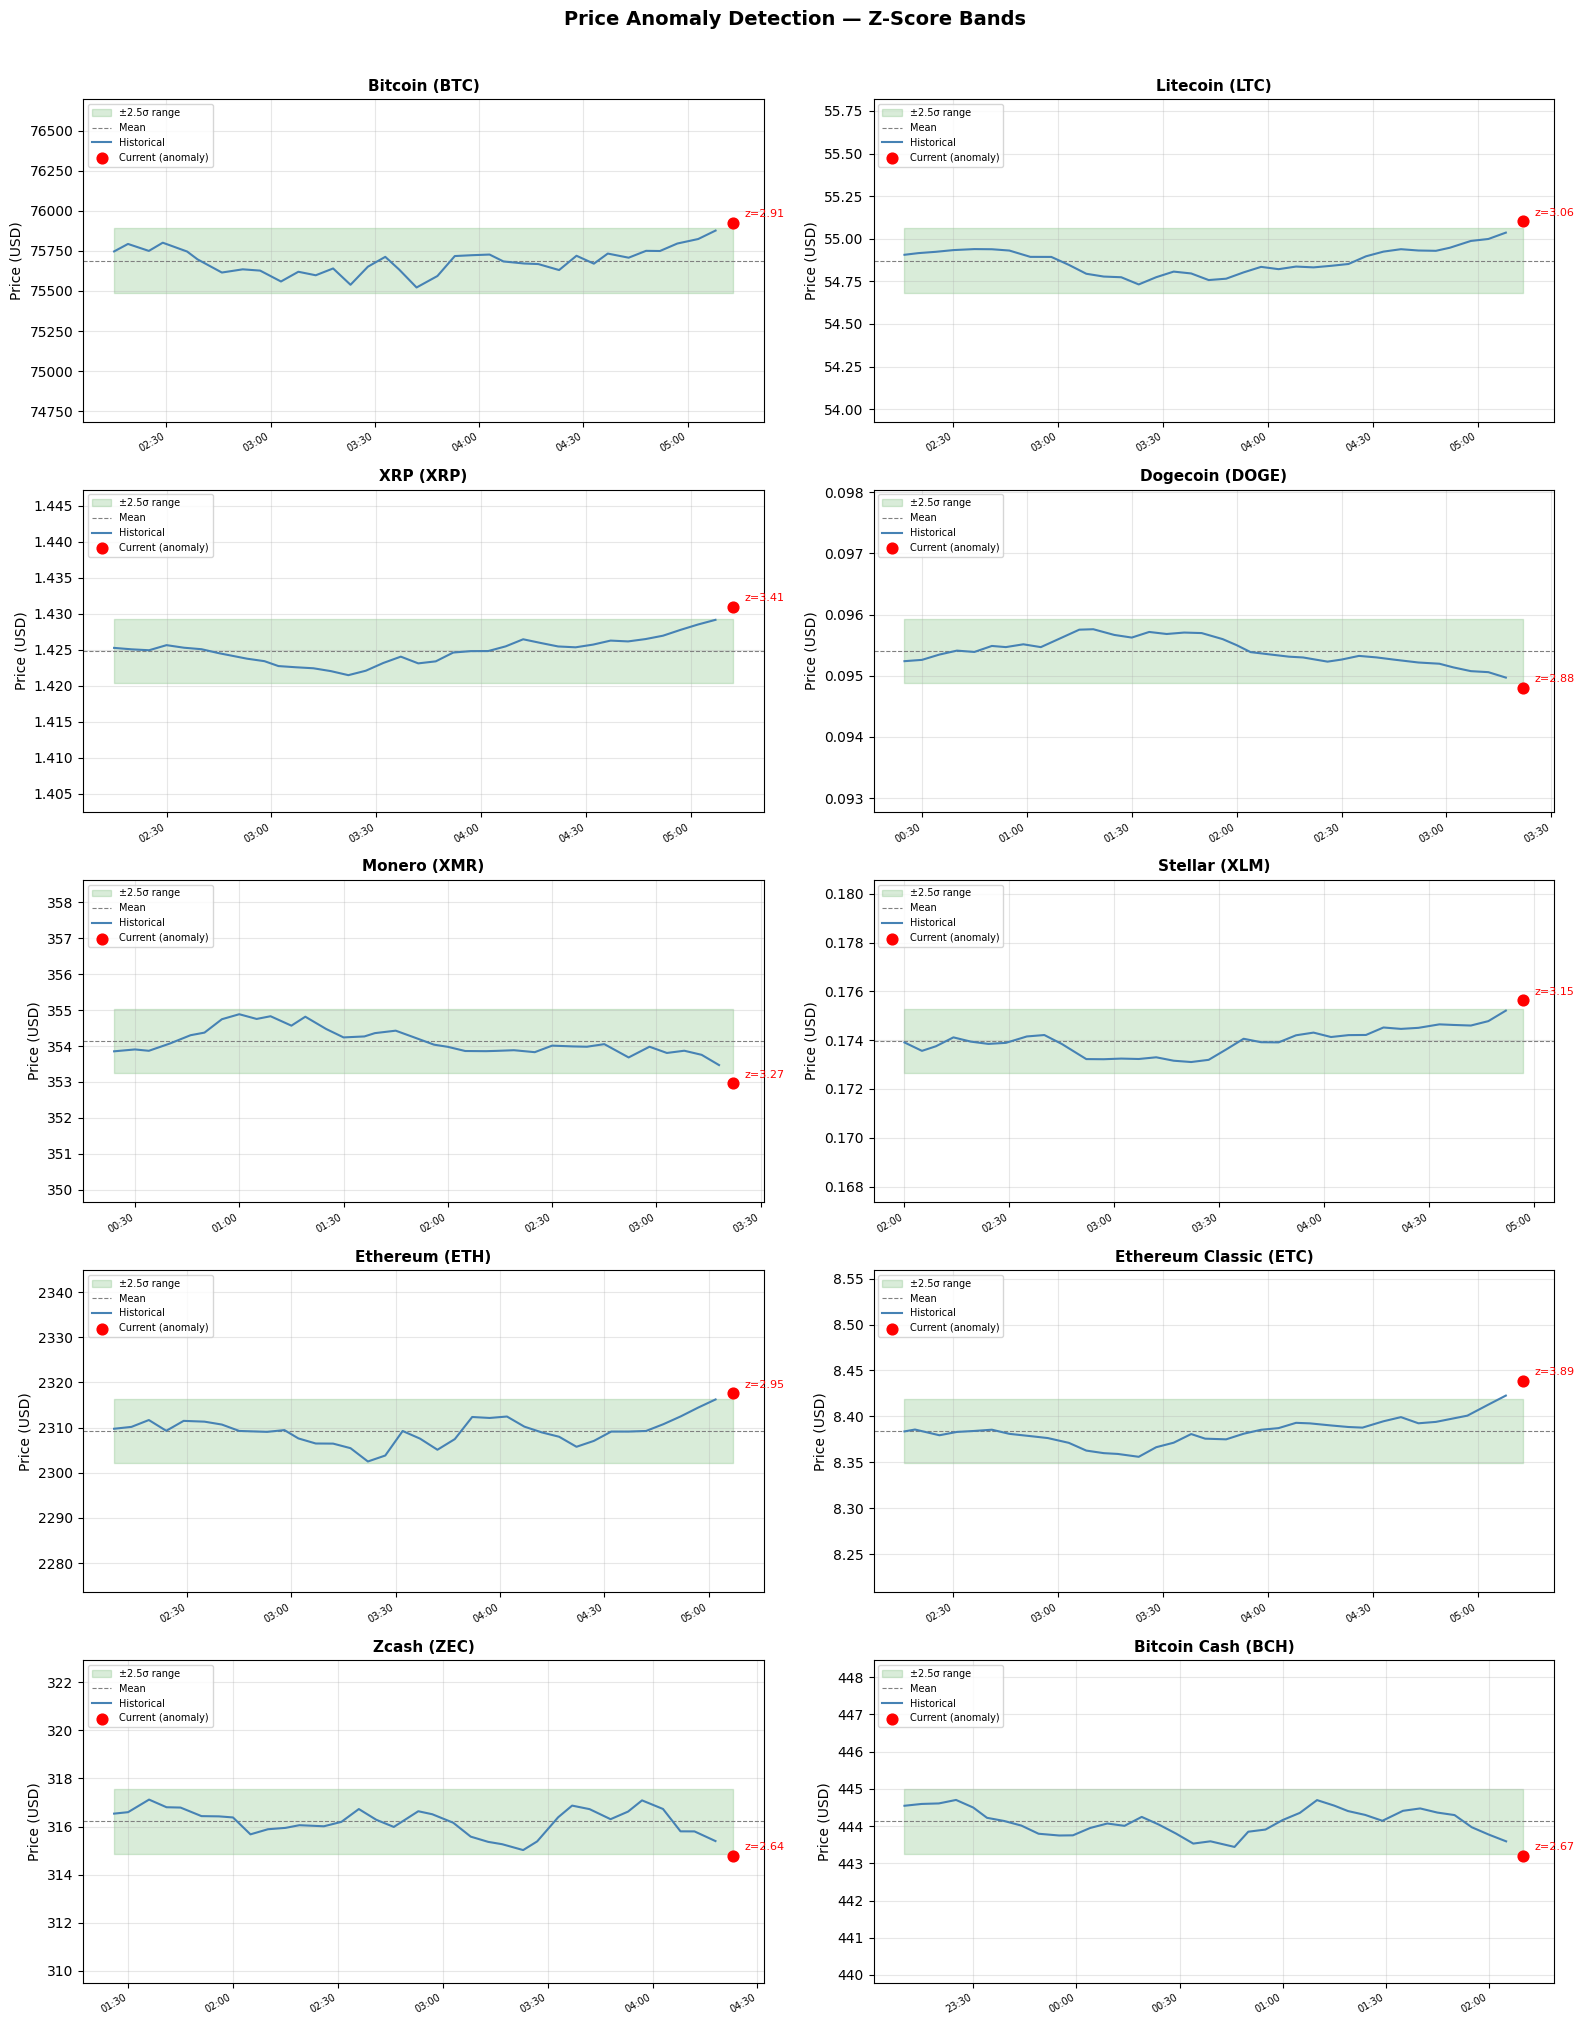

Plot saved to anomaly_plot.png


In [48]:
plot_anomalies(df, z_threshold=2.5)
